# Example: Binomial Lattice Simulation of Equity Share Price using Real-World Probabilities
In this example, we will construct a binomial lattice model to simulate future equity share prices using real-world probabilities estimated from historical data.

> __Learning Objectives:__
>
> The objective of this example is to familiarize students with applying simple probability mass functions to predict future uncertain quantities such as commodity prices, equity share prices, interest rates, etc. After completing this example, students should be able to:
>
> * __Model structure:__ Understand the structure and implementation of binomial lattice models for asset price prediction.
> * __Parameter estimation:__ Estimate real-world probabilities and up and down move magnitudes from historical stock price data, and use them to build and populate a binomial price tree.
> * __Model evaluation:__ Compare model predictions with actual market observations and evaluate performance using model-based standard-deviation bands.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time period. 

Let's load the `original_dataset::Dict{String,DataFrame}` variable by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. We'll save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # what is this doing?
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

How many firms do we have with the full number of trading days? Let's use [the `length(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.length), which works for dictionaries in addition to arrays, sets, and other collections.

In [5]:
length(dataset) # tells us how many keys are in the dictionary (how many firms in our dataset?)

424

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values.

In [7]:
TSIM = 63; # number of trading days to simulate
Δt = (1.0/252); # step size: 1 trading day in units of years

___

## Task 1: Test the lattice model using an example from Hull
Let's start by calculating the hypothetical share price from an example (reproduced from Chapter 13 of Hull) before diving into historical data analysis. The lattice in this example has three levels (`L=0,1,2`), with an initial share price of $S_{\circ}=20.0$ USD. An `up` move has a probability of `p = 0.6523` and a magnitude of `u = 1.1`, while a `down` move has a magnitude of `d = 0.9`.

Calculating the future share price with a binomial lattice requires setting the model's parameters, including the initial share price (as a `Float64`), the number of time steps to simulate into the future, so the tree has that many levels beyond the root (as an `Int64`), the up and down move magnitudes (as `Float64` values), and the probability of an up move (as a `Float64`):

In [8]:
Sₒ,T,u,d,p = 20.0,2,1.1,0.9,0.6523;

Once these values are set, we use [the `build(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyBinomialEquityPriceTree},%20NamedTuple}) to create an empty lattice model of [type `MyBinomialEquityPriceTree`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBinomialEquityPriceTree), which is then passed to [the `populate(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.populate-Tuple{MyBinomialEquityPriceTree}) using the [Julia piping `|>` operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping). 

The [`populate(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.populate-Tuple{MyBinomialEquityPriceTree}) calculates the prices and probabilities of each node, which are of [type `MyBiomialLatticeEquityNodeModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBiomialLatticeEquityNodeModel), in the tree:

In [9]:
test_hull_model = build(MyBinomialEquityPriceTree, (
        u = u, d = d, p = p)) |> (x-> populate(x, Sₒ = Sₒ, h = T));

In [10]:
typeof(test_hull_model) |> T-> fieldnames(T)

(:u, :d, :p, :μ, :T, :connectivity, :levels, :ΔT, :data)

In [11]:
test_hull_model.data[2].price

18.0

### Check: Do we reproduce the Hull tree values?
Let's compare the price values we calculated to those reported by Hull. 

> __Test:__ First, we populate the `hull_price_dictionary` dictionary, which holds `key=>value` pairs encoding the actual data for each node in the tree. In this dictionary, the `keys` are the node indices, while the `values` in the dictionary are the price values at that node. Then, we'll compare these values with those calculated in our lattice model.

Build the dictionary of Hull prices:

In [12]:
hull_price_dictionary = Dict(0=>20.0, 1=>22.0,2=>18.0,3=>24.2,4=>19.8,5=>16.2);

Now, let's build a table of the Hull values and compare these to our computed values using [the `pretty_table(...)` function exported by the `PrettyTables.jl` package](https://github.com/ronisbr/PrettyTables.jl) within a for loop. 

For each iteration of the for loop:
* We capture the node index `i`, the share price from Hull, and our computed price at that node from the binomial tree
* We use the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox), with a relative tolerance `rtol = 1e-4`, to check if our computed price agrees with the price reported by Hull. If yes, a value of `true` is reported; otherwise, `false`

What do we observe?

In [13]:
let

    # initialize -
    number_of_nodes = length(test_hull_model.data);
    hull_test_data_table = DataFrame();
    
    # populate the DataFrame (by rows)
    for i ∈ 0:(number_of_nodes-1)
        
        row_data = (
            node = i,
            hull_price = hull_price_dictionary[i],
            our_price =  test_hull_model.data[i].price, 
            isapproxequal = isapprox(hull_price_dictionary[i], test_hull_model.data[i].price, rtol=1e-4)
        );
        
        push!(hull_test_data_table, row_data)
    end
    pretty_table(hull_test_data_table, 
            table_format = TextTableFormat(borders = text_table_borders__compact))
end;

 ------- ------------ ----------- ---------------
   node   hull_price   our_price   isapproxequal 
  Int64      Float64     Float64            Bool 
 ------- ------------ ----------- ---------------
      0         20.0        20.0            true
      1         22.0        22.0            true
      2         18.0        18.0            true
      3         24.2        24.2            true
      4         19.8        19.8            true
      5         16.2        16.2            true
 ------- ------------ ----------- ---------------


___

## Task 2: Estimate lattice parameters from historical data
After validating our lattice implementation, it's time to utilize historical data to compute a share price prediction. To create a binomial lattice model for future share prices, we must estimate three critical parameters: $p$, $u$, and $d$.

> __Parameter Definitions__
>
>* The $p$ parameter represents the probability of a share price increase or an `up` move between two consecutive periods $j\rightarrow{j+1}$. Since a binary lattice model only allows `up` and `down` moves, the probability of a `down` move is $1-p$.
>* The $u$ parameter represents the magnitude of an `up` move. If $S_{j}$ denotes the share price in period $j$, and $S_{j+1}$ is the share price in the next period, then an `up` move results in $S_{j+1} = u\cdot{S}_{j}$.
>* The $d$ parameter represents the magnitude of a `down` move. If $S_{j}$ denotes the share price in period $j$, and $S_{j+1}$ is the share price in the next period, then a `down` move results in $S_{j+1} = d\cdot{S}_{j}$.

To start, let's select a firm from the dataset to explore.

In [14]:
# random_firm_ticker = rand(list_of_tickers);
random_firm_ticker = "AAPL"
random_firm_index = findfirst(x-> x == random_firm_ticker, list_of_tickers);
random_firm_data = dataset[random_firm_ticker];

In [15]:
random_firm_data

Row,volume,volume_weighted_average_price,open,close,high,low,timestamp,number_of_transactions
,Float64,Float64,Float64,Float64,Float64,Float64,DateTime,Int64
1,3.93215e8,19.4749,19.745,19.3207,19.775,19.3011,2014-01-03T05:00:00,148584
2,4.13437e8,19.3213,19.1946,19.4261,19.5286,19.0571,2014-01-06T05:00:00,131664
3,3.17731e8,19.3329,19.44,19.2871,19.4986,19.2116,2014-01-07T05:00:00,107327
4,2.58747e8,19.4038,19.2432,19.4093,19.4843,19.2389,2014-01-08T05:00:00,86874
5,2.79621e8,19.2943,19.5286,19.1614,19.5307,19.1196,2014-01-09T05:00:00,93562
6,3.05283e8,19.0659,19.2796,19.0336,19.3143,18.9682,2014-01-10T05:00:00,113063
7,3.79443e8,19.1801,18.9254,19.1332,19.375,18.9243,2014-01-13T05:00:00,130227
8,3.34937e8,19.4033,19.2221,19.5139,19.5261,19.2021,2014-01-14T05:00:00,114856
9,3.9389e8,19.9105,19.7686,19.9057,20.0071,19.7021,2014-01-15T05:00:00,136942


### Estimate the u, d, and probability p parameters from the data
Let's estimate the up $u$ and down $d$ factors and the probability $p$ from historical data.

__Initialize__: Given the growth rate sequence $\{g_{2},g_{3},\dots,g_{T}\}$ for firm $(i)$ (we omit the superscript $i$ for simplicity) and a time step $\Delta{t} > 0$ (units: years), initialize an empty up-factor list $U$ and an empty down-factor list $D$.

1. For $t = 2,3,\dots,T$, __do__:
    - If $g_{t} > 0$, then append $e^{g_{t}\Delta{t}}$ to the up-factor collection $U$.
    - If $g_{t} < 0$, then append $e^{g_{t}\Delta{t}}$ to the down-factor collection $D$.
    - If $g_{t} = 0$, skip (no price change).
2. Compute the up factor $u$ as the mean of the up factors collection $U$: $u = \frac{1}{|U|} \sum_{v \in U} v$.
3. Compute the down factor $d$ as the mean of the down factors collection $D$: $d = \frac{1}{|D|} \sum_{v \in D} v$.
4. Compute the probability $p$ as the fraction of all observed steps that are up moves: $p = |U|/(T-1)$, where a zero-change day counts in the denominator but joins neither collection. The estimator requires at least one up move and one down move in the sample.

We use daily data; thus, the natural time frame between $S_{j-1}$ and $S_{j}$ is a single day. However, it is more convenient to use an annualized value for the $g$ parameter; thus, we let $\Delta{t} = 1/252$, i.e., the fraction of a year that corresponds to a single trading day.

The [`log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) takes the cleaned dataset $\mathcal{D}$, which contains $T$ days of data for each firm, and our selected ticker, and computes the growth rate series for that firm as a function of time. 

The data is returned as a length $T-1$ vector, one growth value per trading-day step. We store the data in the `log_growth_array::Array{Float64,1}` variable:

In [16]:
log_growth_array = log_growth_matrix(dataset, random_firm_ticker) # array holding growth rate time series

2766-element Vector{Float64}:
 -1.9954223478275546
  0.15124876922831154
  0.9224750663536962
 -1.4261203338251638
 -3.0008957287125435
  1.5049147899343094
  2.9156076155145367
  6.502627170431676
 -1.2561327051214097
 -4.024741418592851
  0.3164555755863404
  3.1033658421029613
 -0.6383305505446158
  ⋮
  0.00935838698715206
  2.702995377102388
  2.5465265271513293
 -2.325529514930973
 -0.7888121514647656
  3.27667430452004
  1.6089944655721826
  2.6547619721872575
  1.4556917537856608
 -3.6286559032528003
 -2.934268163874707
 -1.5398398549769603

Using the `log_growth_array::Array{Float64,1}`, we compute the expected up factor $\bar{u}$, expected down factor $\bar{d}$, and estimated up probability $\bar{p}$ by passing the growth-rate data to a `RealWorldBinomialProbabilityMeasure` instance.

> __Syntax sugar__: [The `RealWorldBinomialProbabilityMeasure` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.RealWorldBinomialProbabilityMeasure) is constructed with `RealWorldBinomialProbabilityMeasure()`, and the instance itself is callable: Julia dispatches the call to a functor method that computes $\bar{u}$, $\bar{d}$, and $\bar{p}$ from the growth rate time series in the `log_growth_array::Array{Float64,1}` variable. So we construct an object, then call it like a function. This is a neat Julia trick, right?

What values did we obtain for our selected firm?

In [17]:
(ū,d̄,p̄) = (RealWorldBinomialProbabilityMeasure())(log_growth_array; Δt = (1.0/252.0))

(1.010594785254532, 0.9893009316134485, 0.5509761388286334)

### Build binomial lattice model using historical $(u,d,p)$ parameters
Let's construct an instance of [the `MyBinomialEquityPriceTree` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBinomialEquityPriceTree) using the estimated values for `(u,d,p)`. This enables us to calculate the prices and probabilities in the tree. We store the populated model in the variable `random_test_model` for future use.

We use the `TSIM` constant (set in the Setup section) as the number of future trading days to simulate. Time steps are represented in the tree as levels `L = 0,1,..., TSIM`, where each level represents $\Delta{t}$ units of time, which is a trading day. 

Next, we randomly specify the `start_index` as the trading day index in the dataset, which will serve as the tree's starting point or `L = 0`. Finally, we set the variable `Sₒ`, which corresponds to the initial price per share at the root of the tree; we use the [volume-weighted average price (VWAP)](https://en.wikipedia.org/wiki/Volume-weighted_average_price) as the initial condition:

In [18]:
start_index = rand(1:(maximum_number_trading_days - TSIM - 1))
stop_index = start_index + TSIM
println("Visualize Firm-$(random_firm_index) between trading days ($(start_index) -> $(stop_index - 1))")

Visualize Firm-4 between trading days (1147 -> 1209)


In [19]:
Sₒ = random_firm_data[start_index,:volume_weighted_average_price];
random_test_model = build(MyBinomialEquityPriceTree, (
    u = ū, d = d̄, p = p̄)) |> (model -> populate(model, Sₒ = Sₒ, h = TSIM));
println("Starting simulation from Sₒ = $(Sₒ) USD/share")

Starting simulation from Sₒ = 48.2107 USD/share


#### Visualize price distribution at tree level L
__Unhide__ the code block below to see how we plotted the distribution of possible share prices and their associated probabilities at level `L = 10` of our binomial tree. 

> __What do we expect?__ We expect to see a discrete probability distribution where each possible price outcome has a specific probability based on the number of paths that lead to that price level. The distribution should reflect the binomial nature of our model, with probabilities concentrated around the most likely price outcomes.

What do we observe?

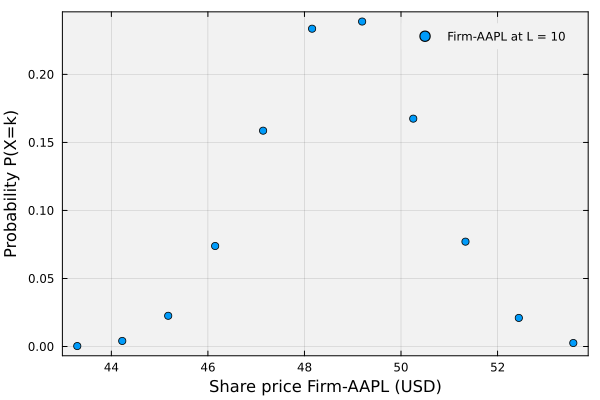

In [20]:
let
    L = 10;
    price_array = random_test_model.levels[L] .|> x-> random_test_model.data[x].price
    probability_array = random_test_model.levels[L] .|> x-> random_test_model.data[x].probability;
    scatter(price_array, probability_array, label="Firm-$(random_firm_ticker) at L = $(L)")
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    xlabel!("Share price Firm-$(random_firm_ticker) (USD)", fontsize=18)
    ylabel!("Probability P(X=k)", fontsize=18)
end

### Visualize binomial lattice simulation
Next, let's examine how the binomial model simulations compare with market observations. In particular, we'll compute the expected value and the variance of the simulated price as a function of time, i.e., at each level in the tree using the local [`𝔼(...)`](src/Compute.jl) and [`Var(...)` functions](src/Compute.jl).

The `levels` array holds the indices of the tree levels, i.e., the time slices. The [`𝔼(...)`](src/Compute.jl) and [`Var(...)` functions](src/Compute.jl) take the `random_test_model` tree model and the `levels` array and return the expectation and the variance, respectively.

In [21]:
levels = [k for k ∈ 0:(TSIM-1)]
expectation = 𝔼(random_test_model, levels); # compute the expected value
variance = Var(random_test_model, levels); # compute the variance

#### Summary
__Unhide__ the code block below to see how we plotted the model simulations and the observed prices for the selected firm using a binomial lattice model.

The dashed line represents the expected share price predicted by the lattice model, while the shaded regions denote the expectation plus or minus $z\sigma$ for $z=$ `1.0, 1.96, 2.576`. The solid red line with circles represents the [observed VWAP price](https://en.wikipedia.org/wiki/Volume-weighted_average_price) for this firm and date range.

Depending upon the selected ticker and the random start date, the observed price (red line with points) may or may not lie within the $\pm\,{z}\cdot\sigma$ bands, where `z = {1, 1.96, 2.576}` are shown in progressively lighter shades of blue. The dashed dark blue line shows the expected value.

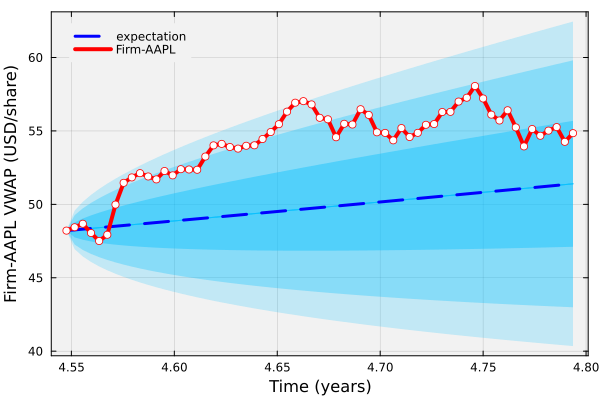

In [22]:
let 

    # initialize -
    L68 = expectation[:,2] .- sqrt.(variance[:,2])
    U68 = expectation[:,2] .+ sqrt.(variance[:,2])
    L95 = expectation[:,2] .- 1.96*sqrt.(variance[:,2])
    U95 = expectation[:,2] .+ 1.96*sqrt.(variance[:,2])
    L99 = expectation[:,2] .- 2.576*sqrt.(variance[:,2])
    U99 = expectation[:,2] .+ 2.576*sqrt.(variance[:,2])

    T_range = range(start_index,stop=stop_index-1,step=1) |> collect 
    T_sim = T_range*Δt .- Δt

    plot(T_sim, expectation[:,2], fillrange=L68, c=:deepskyblue1, alpha=0.4, label="")
    plot!(T_sim, expectation[:,2], fillrange=U68, c=:deepskyblue1, alpha=0.4, label="")
    plot!(T_sim, expectation[:,2], fillrange=L95, c=:deepskyblue1, alpha=0.3, label="")
    plot!(T_sim, expectation[:,2], fillrange=U95, c=:deepskyblue1, alpha=0.3, label="")
    plot!(T_sim, expectation[:,2], fillrange=L99, c=:deepskyblue1, alpha=0.2, label="")
    plot!(T_sim, expectation[:,2], fillrange=U99, c=:deepskyblue1, alpha=0.2, label="")
    plot!(T_sim, expectation[:,2],c=:blue, lw=3,ls=:dash, label="expectation")
    plot!(T_sim, random_firm_data[levels .+ start_index, :volume_weighted_average_price],  
        lw=4, c=:red, label="Firm-$(random_firm_ticker)", legend = :topleft)
    scatter!(T_sim, random_firm_data[levels .+ start_index, :volume_weighted_average_price], label="", 
        msc=:red, mc=:white)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

    xlabel!("Time (years)", fontsize=18)
    ylabel!("Firm-$(random_firm_ticker) VWAP (USD/share)", fontsize=18)
end

### Check: Was this a successful simulation?
Determining whether a model accurately represents data can be done in various ways, but we will utilize a simple, straightforward functional test. 

> __Functional test__
> 
> * __Success__: If the observed price falls within a specified lower bound ($L_{j}$) and upper bound ($U_{j}$) for all times $t_j$ within a given interval ($t_{j}\in\mathcal{I}_{k}$), then the model is deemed a `success.`
> * __Failure__: However, if the observed price falls outside either bound __at any point__, the simulation is considered a `failure.`

Note that this is an in-sample check: the parameters were estimated from the full price history, including the evaluation window.

So, did we succeed or fail?

In [23]:
let
    z = 2.576
    L = expectation[:,2] .- z*sqrt.(variance[:,2])
    U = expectation[:,2] .+ z*sqrt.(variance[:,2])
    
    # check the bounds: if below L, or above U then simulation failed
    success_flag = true;
    for k ∈ 1:TSIM
        
        price_value = random_firm_data[start_index+k-1,:volume_weighted_average_price];    
        if (price_value < L[k]) || (price_value > U[k])            
            success_flag = false;
            break;
        end
    end

    println("The simulation of the VWAP for $(random_firm_ticker) between ($(start_index) -> $(stop_index - 1)) was successful: $(success_flag)")
end

The simulation of the VWAP for AAPL between (1147 -> 1209) was successful: false


___

## Summary

This example built a binomial share-price lattice, verified its implementation against a known Hull example, and then estimated real-world lattice parameters from historical equity data.

> __Key Takeaways:__
>
> * __A binomial lattice evolves through two one-step outcomes:__ The up factor, down factor, and transition probability determine the possible prices and their probabilities at each future time.
> * __Historical estimation turns the lattice into a real-world model:__ Observed growth-rate data provide estimates of move magnitudes and the physical probability used for forecasting rather than risk-neutral valuation.
> * __Model validation must compare predictions with observations:__ Expected paths and probability bands are informative, but a stringent functional test can fail when even one observed price leaves the selected bounds.

A lattice is useful only to the extent that its transition assumptions, parameter estimates, and validation criterion are appropriate for the question being asked.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___